# 프로젝트: KoChatGPT 업그레이드 하기

# 1. Data 준비

아래 깃허브 레포지토리를 clone해주세요.
```
$ git clone https://github.com/airobotlab/KoChatGPT
# $ cp -r /content/KoChatGPT/colossalai_ChatGPT_230319/chatgpt /content/chatgpt

# 수정:
$ cp -r KoChatGPT/colossalai_ChatGPT_230319/chatgpt chatgpt
```

또는 터미널에서 진행

```# !git clone https://github.com/airobotlab/KoChatGPT
# !cp -r KoChatGPT/colossalai_ChatGPT_230319/chatgpt chatgpt1
```

In [7]:
!pip install datasets
!pip install loralib
!pip install trl
!pip install accelerate
!pip install transformers  
# !pip install transformers==4.40.0  # 현재 version 5.3에서 한글 깨짐 -> 4.40.0 사용 -> 원복

##### 현재 코랩 버전에서는 일부 라이브러리를 사용하는데 장애가 있어 원본 소스 코드의 일부를 수정한 뒤 진행하겠습니다. 다음 코드를 위 clone 이후 동작시켜야합니다.

In [9]:
# mv /home/jovyan/work/chatgpt . 로 현재 dir 이동후 진행

import os

modifications = [
    {
        "file": "chatgpt/trainer/callbacks/save_checkpoint.py",
        "changes": [
            {"line": 3, "old": "from chatgpt.trainer.strategies import ColossalAIStrategy, Strategy",
             "new": "from chatgpt.trainer.strategies import Strategy"},
            {"line": 71, "old": "only_rank0 = not isinstance(self.strategy, ColossalAIStrategy)",
             "new": "            only_rank0 = not isinstance(self.strategy)"},
        ],
    },
    {
        "file": "chatgpt/trainer/strategies/__init__.py",
        "changes": [
            {"line": 1, "old": "from .colossalai import ColossalAIStrategy", "new": ""},  # 삭제
            {"line": 5, "old": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy', 'ColossalAIStrategy']",
             "new": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy']"},
        ],
    },
    {
        "file": "chatgpt/dataset/reward_dataset.py",
        "changes": [
            {"line": 3, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ],
    },
    {
        "file": "chatgpt/trainer/base.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    },
    {
        "file": "chatgpt/trainer/rm.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    }
]


def modify_file(file_path, changes):
    """파일에서 지정된 줄을 찾아 내용을 수정하는 함수"""

    if not os.path.exists(file_path):
        print(f"⚠️ 파일이 존재하지 않습니다: {file_path}")
        return

    with open(file_path, "r", encoding="utf-8") as file:
        lines = file.readlines()

    modified = False

    for change in changes:
        line_index = change["line"]
        if 0 <= line_index < len(lines):
            if lines[line_index].strip() == change["old"]:
                lines[line_index] = change["new"] + "\n"
                modified = True
            else:
                print(f"⚠️ {file_path} 파일의 {change['line']}번째 줄이 예상과 다릅니다.")
                print(f"   예상: {change['old']}")
                print(f"   실제: {lines[line_index].strip()}")

    if modified:
        with open(file_path, "w", encoding="utf-8") as file:
            file.writelines(lines)
        print(f"✅ 수정 완료: {file_path}")
    else:
        print(f"⚠️ {file_path} 수정할 내용이 없습니다.")

for mod in modifications:
    modify_file(mod["file"], mod["changes"])

✅ 수정 완료: chatgpt/trainer/callbacks/save_checkpoint.py
✅ 수정 완료: chatgpt/trainer/strategies/__init__.py
✅ 수정 완료: chatgpt/dataset/reward_dataset.py
✅ 수정 완료: chatgpt/trainer/base.py
✅ 수정 완료: chatgpt/trainer/rm.py


##### 소스 코드는 잘 불러와지는지, 필수 requirement들은 잘 설치되어 있는지 확인

In [8]:
import torch
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd
import numpy

print("Torch version:{}".format(torch.__version__)) # Torch version:1.12.1
print("Cuda version: {}".format(torch.version.cuda)) # Cuda version: 11.3
print("transformers version: {}".format(transformers.__version__)) # transformers 4.28.0
print("GPU 사용 가능여부: {}".format(torch.cuda.is_available()))

# 만일 아래 모듈이 불러와지지 않는다면 Clone 및 수정을 잘 진행했는지 확인해주세요.
from chatgpt.trainer.strategies import NaiveStrategy

Torch version:2.7.1+cu118
Cuda version: 11.8
transformers version: 5.3.0
GPU 사용 가능여부: True


# 2. Base model and Dataset for RLHF

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "skt/kogpt2-base-v2"  # "monologg/koelectra-base-v3-discriminator" 

# tokenizer = AutoTokenizer.from_pretrained(model_name)
from transformers import PreTrainedTokenizerFast
tokenizer = PreTrainedTokenizerFast.from_pretrained(model_name,
                                                    bos_token='</s>', eos_token='</s>', unk_token='<unk>',
                                                    pad_token='<pad>', mask_token='<mask>')

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


- 입력받아 처리할 수 있는 최대 토큰 수 확인

In [10]:
tokenizer.model_max_length

1000000000000000019884624838656

- model.config.n_positions : 모델이 설계상 처리할 수 있는 최대 토큰 길이(최대 시퀀스 길이, context length)

In [11]:
model.config.n_positions

1024

In [12]:
input_txt = "바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까."

In [13]:
tokens = tokenizer(input_txt).tokens()

input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].numpy()

In [14]:
pd.options.display.max_columns = 40
pd.options.display.max_rows = 60
df = pd.DataFrame([tokens, input_ids[0]], index=["kogpt-2_tokens", "Input_IDs"])
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
kogpt-2_tokens,▁바람,도,▁없는,▁공중에,▁수직,의,▁파,문을,▁내,이며,▁고,요,히,▁떨어지는,▁오동,잎은,▁누,구의,▁발자,취,▁입,니까,.
Input_IDs,10891,7235,9712,49207,14438,8143,9203,9941,9094,9639,9065,8084,8811,21215,34769,19985,9669,10139,21626,8408,9241,23775,389


-  디코딩 성능 확인

In [15]:
max_length=128
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output_greedy = model.generate(input_ids, max_length=max_length, do_sample=False)
print(tokenizer.decode(output_greedy[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.'
"그렇다면 그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리


시퀀스가 반복되어 출력되는군요.
그리디 서치 디코딩시 발견되는 전형적인 현상입니다.

- 이번엔 빔 서치 디코딩을 사용하고 n-gram 패널티까지 부과해보겠습니다.

In [16]:
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output_beam = model.generate(input_ids, max_length=max_length, num_beams=10, no_repeat_ngram_size=2,
                             do_sample=False)
print(tokenizer.decode(output_beam[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.'
"그렇지 않습니다."
"어떻게 된 일입니까?"
그녀는 고개를 갸웃거렸다.
"아니, 그게 무슨 말씀이신지 모르겠습니다만."
"무슨 말씀인지 알 수가 없군요."
아무런 대답도 하지 않은 채 그녀는 고개를 끄덕였다.
"그래, 알았어."
그녀의 눈에서 눈물이 주르륵 흘러내렸다.
그녀가 다시 입을 열었다.
"정말 죄송합니다, 고마워요, 고맙습니다"
"


- 이번엔 샘플링 기법까지 추가해 보겠습니다.

In [17]:
output_beam = model.generate(input_ids, max_length=max_length, num_beams=7, no_repeat_ngram_size=2,
                             do_sample=True, temperature=2.0, top_k=50)
print(tokenizer.decode(output_beam[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까. 저는 오늘이 오십일일째를 맞으러 가는 날이에요."
"정말이지요! 정말로 내일이 오갑일세!"
정말로 고마워 죽겠다!
"그러게 말입니다."
그런데도 고개가 절로 끄덕이는 것은 무엇 때문일까?
"아니오. 내일은 꼭 저희와 함께 가야 해요. 제발 그러세요. 오늘도 저를 만나러 갑시다."
고맙다는 인사도 제대로 하지 못한 채 내뱉는 말


- top_p 샘플링 기법도 사용해보겠습니다.

In [18]:
output_beam = model.generate(input_ids, max_length=max_length, num_beams=7, no_repeat_ngram_size=2,
                             do_sample=True, top_p=0.90)
print(tokenizer.decode(output_beam[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까."
"그렇습니다, 선생님. 저는 선생님의 발자취를 따라가기로 했습니다만."
"선생님, 저의 발자취는 어디로 가셨습니까?"
아무런 대답도 하지 않은 채 고개를 끄덕였다.
"무슨 말씀이신지요? 선생님이 저를 찾아오셨을 때 선생님은 저에게 이렇게 말씀하셨습니다."
선생님의 말이 끝나기가 무섭게 아랑곳하지 않고 아빠가 물었다.
"저도 선생님을 찾아왔습니다. 저도 저와


## Dataset 정의

- SFT를 시도할 initial 모델에 쓸 데이터셋

In [19]:
import json
import os

# data_path_1_SFT = 'KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl'
data_dir = os.path.expanduser('~/work/KoChatGPT/data_kochatgpt')
data_path_1_SFT = os.path.join(data_dir, 'kochatgpt_1_SFT.jsonl')

with open(data_path_1_SFT, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

print(len(list_data_dict))
list_data_dict[:3]

12000


[{'prompt': '불고기용 고기 한우에요?',
  'completion': "'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.",
  'tokens': 193},
 {'prompt': '쓰던 앱이 유료로 전환됐어',
  'completion': "'어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 유료 전환된 앱은 기존 무료 앱에서 추가적인 기능이나 서비스를 제공하는 경우가 많습니다. 이 경우, 유료 전환 이전 가격이 매우 저렴하거나 무료인 경우가 많으므로, 앱을 계속 사용하려면 추가적인 비용을 지불해야 할 수 있습니다. 하지만, 유료 전환 이후에는 기존 사용자 또는 새로운 사용자 모두가 추가 기능과 높은 품질의 서비스를 이용할 수 있게 됩니다. 따라서, 앱 개발자는 유료 모델로 전환함으로써 앱의 수익을 증가시키고 더 나은 서비스를 제공할 수 있습니다.",
  'tokens': 288},
 {'prompt': '여친이랑 다툼',
  'completion': "'저는 인공지능이기 때문에 여친과의 다툼에 대해서는 조언을 드릴 수는 없습니다. 하지만 다투게 되면 상대방의 말을 경청하는 태도와 서로의 감정을 존중하는 것이 중요합니다. 논리적이고 차분한 대화를 통해 문제를 해결해보세요. 그리고 서로를 이해하고 서로의 의견을 수용하는 것이 중요합니다.",
  'tokens': 153}]

- RM에 사용할 데이터셋

In [20]:
# data_path_2_RM = 'KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl'
data_dir = os.path.expanduser('~/work/KoChatGPT/data_kochatgpt')
data_path_2_RM = os.path.join(data_dir, 'kochatgpt_2_RM.jsonl')

with open(data_path_2_RM, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

print(len(list_data_dict))
list_data_dict[:3]

10220


[{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?',
  'completion_0': 'Allow me to answer your question. I know that you are curious about me.',
  'completion_1': '번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.',
  'completion_2': '라이언에게 말했다.',
  'ranking': [2, 1, 0]},
 {'prompt': '개포주공아파트는 몇 단지로 이루어져 있나?',
  'completion_0': '개포주공아파트는 다섯 단지로 이루어져 있습니다.',
  'completion_1': '이날 목송에서 구글상위노',
  'completion_2': '개포주공아파트는 총 27개 단지로 이루어져 있습니다.',
  'ranking': [2, 0, 1]},
 {'prompt': '김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?',
  'completion_0': 'The diameter of the Metallic domain is bigger than the Hyperonic domain.',
  'completion_1': '이 질문은 조금 불분명합니다. 김영삼 대통령이 후보 시절에 어떤 발언을 했고, 누가 그 발언을 문제삼았는지에 따라 답이 다를 수 있습니다.\\n\\n만약 김영삼 대통령이 후보 시절에 지역표심을 겨냥한 발언을 했다는 가정하에, 그 발언을 문제삼은 후보가 누구였는지를 대답하자면, 그 답은 이화선 당시 민주당 대통령 후보가 될 것입니다. 1992년 총선 때, 김영삼 대선후보는 "집값이 오른 노량진역 부근의 부동산 가격은 세월호 폭침 후 \\\'강남 도시재생\\\' 일환으로 상승했다"는 발언을 했습니다. 하지만 이화선 후보는 이 발언을 "전국적으로 경제적 발전이 이루어지지 않은 지방민의 마음을 멀리해지려는 무례한 발언"이라고 비판하며 문

- PPO 학습에 쓰일 데이터

In [21]:
# data_path_3_PPO = 'KoChatGPT/data_kochatgpt/kochatgpt_3_PPO.jsonl'
data_dir = os.path.expanduser('~/work/KoChatGPT/data_kochatgpt')
data_path_3_PPO = os.path.join(data_dir, 'kochatgpt_3_PPO.jsonl')

with open(data_path_3_PPO, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

print(len(list_data_dict))
list_data_dict[:3]

12000


[{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?'},
 {'prompt': '개포주공아파트는 몇 단지로 이루어져 있나?'},
 {'prompt': '김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?'}]

# 3. Supervised Fine-Tuning (SFT)

In [22]:
from typing import Optional, Dict, Sequence
from torch.utils.data import Dataset
from dataclasses import dataclass
import logging
import copy

- 모델과 토크나이저를 불러오겠습니다.

In [52]:
# model = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')

# tokenizer = AutoTokenizer.from_pretrained(
#     'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>',
#     unk_token='</s>', pad_token='</s>',
#     padding_side="right",
#     model_max_length=512,
# )

device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "skt/kogpt2-base-v2"

# model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model = AutoModelForCausalLM.from_pretrained(model_name) # cpu loading
if device == "cuda":
    model = model.half()           # 파라미터를 fp16으로 줄여서
    model = model.to(device)       # 그 다음 GPU로 올리기
else:
    model = model.to(device)

from transformers import PreTrainedTokenizerFast

tokenizer = PreTrainedTokenizerFast.from_pretrained(
    "skt/kogpt2-base-v2",
    bos_token="</s>",
    eos_token="</s>",
    unk_token="<unk>",
    pad_token="<pad>",
    mask_token="<mask>",
)

tokenizer.padding_side = "right"
tokenizer.model_max_length = 128  # 512

print(tokenizer)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


OutOfMemoryError: CUDA out of memory. Tried to allocate 76.00 MiB. GPU 0 has a total capacity of 14.58 GiB of which 13.62 MiB is free. Process 515 has 0 bytes memory in use. Including non-PyTorch memory, this process has 0 bytes memory in use. Of the allocated memory 1.39 GiB is allocated by PyTorch, and 143.72 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

- 모델 인퍼런스 단계에서 사용할 prompt 딕셔너리 템플릿과 SFT 데이터셋 클래스를 정의하겠습니다.

In [44]:
class SFT_dataset(Dataset):

    def __init__(self, data_path_1_SFT: str, tokenizer: transformers.PreTrainedTokenizer, verbose=False):
        super(SFT_dataset, self).__init__()
        logging.warning("Loading data...")

        pattern_instruction = 'prompt'  # instruction
        pattern_output = 'completion'  # response

        with open(data_path_1_SFT, "r", encoding='utf-8-sig') as json_file:
            list_data_dict = json.load(json_file)

        PROMPT_DICT = {
            "prompt_input": (
                "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
            )
        }

        prompt_input = PROMPT_DICT["prompt_input"]

        sources = []
        for example in list_data_dict:
            tmp = prompt_input.format_map(example)
            sources.append(tmp)

        targets = []
        for example in list_data_dict:
            targets.append(f"{example[pattern_output]}{tokenizer.eos_token}")
        examples = [s + t for s, t in zip(sources, targets)]

        sources_tokenized = self._tokenize_fn(sources, tokenizer)  # source
        examples_tokenized = self._tokenize_fn(examples, tokenizer)  # source + target

        input_ids = examples_tokenized["input_ids"]
        labels = copy.deepcopy(input_ids)
        for label, source_len in zip(labels, sources_tokenized["input_ids_lens"]):
            label[:source_len] = -100 
            # -100 설명
            # -100은 “여기 토큰은 무시해라”는 표시용 마스크 값
            # 프롬프트(instruction) 구간의 라벨을 전부 -100으로 교체
            # PyTorch nn.CrossEntropyLoss는 기본적으로 ignore_index=-100라서,
            # 이 부분은 loss에 기여하지 않고, 해당 토큰들에 대해서는 gradient도 흘러가지 않습니다
            # SFT에서는 보통:
            # 입력: ### Instruction ... ### Response: + 정답 completion
            # 출력(라벨): Response(응답) 부분만 정답으로 보고, 
            # Instruction 부분은 단지 conditioning 컨텍스트로만 사용하고 싶습니다.
            # 그런데 HuggingFace 스타일로 causal LM을 학습할 때는 관례상:
            # input_ids = prompt + completion
            # labels = prompt + completion를 그대로 두고,
            # loss를 계산하고 싶지 않은 구간(여기서는 prompt)을 -100으로 마스킹해서
            # CrossEntropyLoss가 무시하게 만듭니다.
            # 그 결과:
            # 모델은 여전히 프롬프트까지 포함한 전체 시퀀스를 autoregressive하게 인코딩하지만,
            # 업데이트는 completion 토큰들에 대해서만 이루어져서 
            # “질문을 얼마나 잘 예측했는지”는 신경 쓰지 않고,
            # “질문을 보고 답을 얼마나 잘 생성하는지”에만 맞춰집니다.

        data_dict = dict(input_ids=input_ids, labels=labels)

        self.input_ids = data_dict["input_ids"]
        self.labels = data_dict["labels"]
        logging.warning("Loading data done!!: %d"%(len(self.labels)))


    def _tokenize_fn(self, strings: Sequence[str], tokenizer: transformers.PreTrainedTokenizer) -> Dict:
        tokenized_list = [
            tokenizer(
                text,
                return_tensors="pt",
                padding="longest",
                max_length=tokenizer.model_max_length,
                truncation=True,
            )
            for text in strings
        ]
        input_ids = labels = [tokenized.input_ids[0] for tokenized in tokenized_list]
        input_ids_lens = labels_lens = [
            tokenized.input_ids.ne(tokenizer.pad_token_id).sum().item() for tokenized in tokenized_list
        ]
        return dict(
            input_ids=input_ids,
            labels=labels,
            input_ids_lens=input_ids_lens,
            labels_lens=labels_lens,
        )


    def __len__(self):
        return len(self.input_ids)


    def __getitem__(self, i) -> Dict[str, torch.Tensor]:
        return dict(input_ids=self.input_ids[i], labels=self.labels[i])

In [45]:
@dataclass
class DataCollatorForSupervisedDataset(object):

    tokenizer: transformers.PreTrainedTokenizer

    def __call__(self, instances: Sequence[Dict]) -> Dict[str, torch.Tensor]:
        input_ids, labels = tuple([instance[key] for instance in instances] for key in ("input_ids", "labels"))
        input_ids = torch.nn.utils.rnn.pad_sequence(
            input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id
        )
        labels = torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value= -100)
        return dict(
            input_ids=input_ids,
            labels=labels,
            attention_mask=input_ids.ne(self.tokenizer.pad_token_id),
        )

- SFT_dataset 클래스를 사용해 훈련셋을 만들고 data collator 인스턴스 생성

In [46]:
# data_path_1_SFT = 'KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl'
data_dir = os.path.expanduser('~/work/KoChatGPT/data_kochatgpt')
data_path_1_SFT = os.path.join(data_dir, 'kochatgpt_1_SFT.jsonl')

train_dataset = SFT_dataset(data_path_1_SFT=data_path_1_SFT, tokenizer=tokenizer)
data_collator = DataCollatorForSupervisedDataset(tokenizer=tokenizer)

print('input : %s'%train_dataset.input_ids[0])
print('output: %s'%train_dataset.labels[0])


input : tensor([  739,   378,   378,   378, 14659, 13394, 37091, 10651,   383, 25841,
         8006, 14914,   375,  7673, 20479,  8091, 22311,  9036, 30902, 13675,
          375,   378,   378,   378, 41951,   454,  9549, 20549,   383,  8142,
         7192, 14914,   382, 37767, 13753,  8263,  7166,   739,  8352,  7659,
         9594, 25585, 13600,  8022,  9378, 11532,  9887, 11218,  9111, 16691,
        10351, 10561,  9128, 20479,  8091,  9065,  9446,  9036, 28420, 26521,
        10163, 26367,  6958,  9030,  9882, 12317, 25882,  9209, 37194, 10351,
         9036, 12168, 10529, 15989,  9719, 15434, 10552, 11188, 13362,  9036,
        15805, 11300, 11846,  9146, 16691,  9181,  7397, 15806, 13480, 11342,
        17596,  9161, 19996,  9025, 25006, 18595,  9966, 12592, 10751, 11814,
         8711,  9046, 12450,  9117,  7377, 12521,     1])
output: tensor([ -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -10

- 디코딩하는 함수로 정수토큰들의 인코딩 전 원래 문장의 토크나이징 확인

In [47]:
# train_dataset.input_ids[0]를 디코딩해보세요.

def inspect_example(tokenizer, input_ids, labels):
    # 1) input_ids 전체 디코딩 (prompt + completion)
    decoded_input = tokenizer.decode(input_ids, skip_special_tokens=False)
    print("=== input_ids (prompt + completion) ===")
    print(decoded_input)
    print()

    # 2) labels에서 -100을 패딩 토큰 id로 되살린 뒤 디코딩
    labels_np = labels.clone()
    ignore_index = -100
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0

    labels_np[labels_np == ignore_index] = pad_id
    decoded_labels = tokenizer.decode(labels_np, skip_special_tokens=False)

    print("=== labels (loss 계산 대상 토큰 표시용) ===")
    print(decoded_labels)
    print()

    # 3) completion 부분만 보고 싶으면, -100이 아닌 위치만 모아서 디코딩
    target_token_ids = labels[labels != ignore_index]
    decoded_target = tokenizer.decode(target_token_ids, skip_special_tokens=False)

    print("=== target only (응답 부분만) ===")
    print(decoded_target)
    print()

i = 0
input_ids_0 = train_dataset.input_ids[i]
labels_0    = train_dataset.labels[i]

inspect_example(tokenizer, input_ids_0, labels_0)

=== input_ids (prompt + completion) ===
### Instruction(명령어):
불고기용 고기 한우에요?

### Response(응답):'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.</s>

=== labels (loss 계산 대상 토큰 표시용) ===
<pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad>'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.</s>

=== target only (응답 부분만) ===
'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.</s>



- Training arguments를 사용해 trainer 클래스 정의

In [48]:
# training_args = transformers.TrainingArguments(
#     output_dir="test",
#     overwrite_output_dir=True,
#     num_train_epochs=1,
#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=8,
#     warmup_steps=5,
#     prediction_loss_only=True,
#     fp16 = True
#     )
training_args = transformers.TrainingArguments(
    output_dir="test",
    # overwrite_output_dir=True, # 현재 버전에는 없어서 에러 발생
    num_train_epochs=1,
    per_device_train_batch_size=1, # 8,
    per_device_eval_batch_size=8,
    warmup_steps=5,
    prediction_loss_only=True,
    fp16 = True
    )
trainer = transformers.Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset
)

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.58 GiB of which 13.62 MiB is free. Process 515 has 0 bytes memory in use. Including non-PyTorch memory, this process has 0 bytes memory in use. Of the allocated memory 1.39 GiB is allocated by PyTorch, and 143.72 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

- SFT 훈련 (1epoch)

In [36]:
trainer.train()
model.save_pretrained('models/output_1_SFT')

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.58 GiB of which 13.62 MiB is free. Process 515 has 0 bytes memory in use. Including non-PyTorch memory, this process has 0 bytes memory in use. Of the allocated memory 1.41 GiB is allocated by PyTorch, and 121.36 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

loss가 잘 줄어들었나요?

이제 문장 생성 능력을 확인하기 위해 빠르게 허깅페이스의 pipleline 클래스를 사용하여 generator를 만들어보겠습니다.

In [46]:
generator = transformers.pipeline('text-generation', model='models/output_1_SFT', tokenizer=tokenizer)

generation_args = dict(
    num_beams=4,
    repetition_penalty=2.0,
    no_repeat_ngram_size=4,
    eos_token_id=375, # \n
    max_new_tokens=64,
    do_sample=True,
    top_k=50,
    early_stopping=True
)

PROMPT_DICT = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

list_prompt = ['불고기용 고기 한우에요?',
               '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
               '시카고 오헤어 국제공항은 어디에 있어?',
               '오늘 미세먼지 어때?']

list_prompt = [PROMPT_DICT['prompt_input'].format_map({'prompt' : tmp}) for tmp in list_prompt]

list_result = generator(list_prompt, **generation_args)
for prompt, result in zip(list_prompt, list_result):
    print()
    print((result[0]['generated_text']))

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Passing `generation_config` together with generation-related arguments=({'repetition_penalty', 'do_sample', 'max_new_tokens', 'no_repeat_ngram_size', 'top_k', 'eos_token_id', 'num_beams', 'early_stopping'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=64) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer t


### Instruction(명령어):
불고기용 고기 한우에요?

### Response(응답):'��AI����������,����������������.���,�������������������

### Instruction(명령어):
리처드 닉슨이 43대 부통령직을 수행한 년도는?

### Response(응답):'��AI�������,�������������������.���,������������������

### Instruction(명령어):
시카고 오헤어 국제공항은 어디에 있어?

### Response(응답):'��AI����������,���������������.���,�����������������

### Instruction(명령어):
오늘 미세먼지 어때?

### Response(응답):'��AI����������,������������������.���,����������������


- [허깅페이스의 Text generation strategies](https://huggingface.co/docs/transformers/v4.28.1/en/generation_strategies)

주관식 퀴즈

Q. 위 허깅페이스의 Text generation strategies 링크를 참고하여 generation_args에 있는 각 옵션의 기능을 확인하세요. 변경하거나 추가할 수 있는 옵션에는 어떤 것들이 있는지 살펴보세요.
답변을 적어보세요 😀

<details>
<summary> hint </summary>

**주요 Generation Options**

`max_length` : 생성할 텍스트의 최대 길이를 지정합니다. 단, 너무 큰 값은 불필요한 계산을 유발할 수 있습니다.

`min_length` : 생성 텍스트의 최소 길이를 보장합니다.

`do_sample` : 샘플링을 사용할지 여부를 결정합니다. False일 경우 greedy search 혹은 beam search 등 결정론적 방법을 사용합니다.

`num_beams` : beam search 시 고려할 빔의 수를 지정합니다. 값이 클수록 더 다양한 후보를 고려하지만, 계산 비용이 증가합니다.

`temperature` : 샘플링 시 확률 분포의 평탄화 정도를 조절합니다. 낮은 값은 확률 분포를 예리하게 만들어, 높은 값은 다양성을 증가시킵니다.

`top_k` : 샘플링 시 고려할 상위 k개의 후보 토큰만 사용합니다. 높은 값은 다양한 결과를, 낮은 값은 집중된 선택을 유도합니다.

`top_p` (nucleus sampling) : 확률 누적 합이 p에 도달할 때까지의 후보 토큰을 사용합니다. 후보 집합의 크기를 동적으로 조절해, 확률이 낮은 토큰은 배제합니다.

`repetition_penalty` : 동일한 문구나 단어의 반복 생성을 방지합니다. 값이 1보다 크면 반복에 패널티를 부여합니다.

`length_penalty` : beam search 시 문장 길이에 대한 보정을 합니다. 값이 1보다 크면 긴 문장을 선호, 작으면 짧은 문장을 선호합니다.

`no_repeat_ngram_size` : 지정한 크기의 n-그램이 반복되지 않도록 합니다. 예를 들어, 3을 설정하면 동일한 3-그램이 여러 번 등장하지 않습니다.

`early_stopping` : 모든 beam에서 EOS 토큰이 생성되면 조기 종료합니다.

`bad_words_ids` : 생성 과정에서 금지된 단어들의 토큰 ID 리스트를 지정하여, 해당 단어들이 생성되지 않도록 합니다.

`forced_bos_token_id / forced_eos_token_id` : 생성된 텍스트의 시작 혹은 종료 토큰을 강제합니다.

`output_scores / return_dict_in_generate` : 생성 과정의 자세한 정보를 반환할지 여부를 결정합니다. 디버깅이나 후처리를 위해 사용됩니다.
</details>

- SFT 모델의 성능은 어떤가요?

SFT 단계를 최적화하기 위해선 무엇보다도 instruction dataset의 품질과 initial모델의 언어모델링 성능이 중요합니다.

GPT를 새로 pretrain 하여 언어모델 성능을 도약시키는 일은 우리의 학습목표를 넘어서는 일이니 우선은 데이터셋 전처리를 더 수행하고 최상의 디코딩 전략이 적용된 generator를 설계한다면 더 나은 성능을 기대해 볼 수 있을 것입니다.

하지만 지금은 baseline을 빠르게 돌려보는 게 목적입니다.

이제 다음 단계인 reward modeling으로 넘어가 보도록 하겠습니다.

메모리 관리를 위해 캐시를 비우고 넘어가겠습니다.

In [47]:
torch.cuda.empty_cache()

# 4. Reward Model
이번 스텝에서는 RLHF의 두번째 단계인 Reward model을 설계하고 학습해보겠습니다.

필요한 라이브러리들을 불러와 볼까요?

In [48]:
from chatgpt.dataset import RewardDataset
from chatgpt.models.base import RewardModel
from chatgpt.trainer.strategies import NaiveStrategy
from chatgpt.trainer.rm import RewardModelTrainer

from transformers.models.gpt2.configuration_gpt2 import GPT2Config
from transformers.models.gpt2.modeling_gpt2 import GPT2Model

import torch.nn as nn

import random

Import된 라이브러리들을 보면 SFT단계에서 사용했던 것과는 다른 모듈들이 몇 개 눈에 띕니다.

우선 chatgpt 폴더 안에 있는 RM 관련 모듈들이 눈에 띄네요.
NaiveStrategy라는 모듈도 있습니다.

원본 깃헙 레포짓에는 multi GPU를 사용해서도 KoChatGPT를 실습해볼 수 있도록 하고 있지만 우리는 single GPU를 사용해야 하는 환경이므로 학습전략을 고정시켜놓기 위해 해당 모듈을 따로 import했습니다.

마지막엔 허깅페이스의 transformers에서 gpt2 모델 관련 모듈들도 사용하고 있네요.

주관식 퀴즈

Q. SFT 모델의 출력 결과를 Reward model이 받아 어떻게 처리하게 되는지 잠시 생각해봅시다. 여기서 Reward model로 GPT2를 사용하는 이유가 무엇일까요?
답변을 적어보세요 😀
<details>
<summary> hint </summary>

GPT-2를 Reward Model로 선택하는 이유는 다음과 같습니다.

1. 사전 학습(pretraining)의 이점
GPT-2는 대규모 텍스트 데이터에 대해 사전 학습되어 다양한 언어 패턴과 문맥 정보를 이미 학습한 상태입니다. 이를 통해, SFT 모델이 생성한 텍스트에 대해 미세하게 언어적, 문맥적 평가를 수행할 수 있습니다.

2. 아키텍처의 유사성 및 일관성
SFT 모델이 Transformer 기반이라면, GPT-2 역시 같은 Transformer 아키텍처를 사용합니다. 이로 인해 두 모델 간의 표현 공간이 어느 정도 일치할 가능성이 있으며, 텍스트의 흐름이나 품질을 평가하는 데 있어 더 자연스러운 비교가 가능해집니다.

3. 효율성과 구현 용이성
GPT-2는 오픈 소스 커뮤니티에서 널리 사용되고 검증된 모델로, 리소스나 구현 측면에서 안정적입니다. 따라서 복잡한 Reward Model을 처음부터 구축하기보다는, GPT-2를 기반으로 미세 조정하여 활용하는 것이 효율적입니다.

4. 자연스러운 텍스트 생성 및 평가
GPT-2는 이미 언어 생성 능력이 뛰어나므로, 생성된 텍스트의 문법적, 의미적 적합성을 평가할 때 신뢰성 있는 피드백을 제공할 수 있습니다.
</details>

- 이제 Reward model을 설계해 볼까요?

GPTRM_custom 이라는 이름으로 클래스를 선언하겠습니다.

In [50]:
class GPTRM_custom(RewardModel):

    def __init__(self,
                 pretrained: Optional[str] = None,
                 config: Optional[GPT2Config] = None,
                 checkpoint: bool = False,
                 lora_rank: int = 0,
                 lora_train_bias: str = 'none',
                 tokenizer=None) -> None:
        if pretrained is not None:
            model = GPT2Model.from_pretrained(pretrained)
            model.resize_token_embeddings(len(tokenizer))
        elif config is not None:
            model = GPT2Model(config)
        else:
            model = GPT2Model(GPT2Config())
        if checkpoint:
            model.gradient_checkpointing_enable()

        value_head = nn.Linear(model.config.n_embd, 1)
        # model.config.n_embd: GPT-2의 내부 은닉 상태 벡터의 차원(예: 768, 1024 등).
        # 1: 최종적으로 하나의 보상 값(스칼라)을 출력하기 위한 차원.

        super().__init__(model, value_head, lora_rank, lora_train_bias)

        if pretrained is not None:
            self.model = model
            self.pretrained = pretrained


    def save_pretrained(self, dir):
        if self.pretrained is not None:
            self.model.save_pretrained(dir)

위 클래스의 원본 코드는 이 링크에서 확인하실 수 있습니다.

여기서 주의깊게 봐야할 부분은 이니셜라이저의 value_head = nn.Linear(model.config.n_embd, 1) 코드입니다.

주관식 퀴즈

Q. nn.Linear() 레이어의 인자로 model.config.n_embd와 1이 주어졌습니다. model.config.n_embd는 무엇이고 1은 왜 입력된 것일까요?
답변을 적어보세요 😀

<details>
<summary> hint </summary>

- model.config.n_embd: GPT-2의 내부 은닉 상태 벡터의 차원(예: 768, 1024 등).
- 1: 최종적으로 하나의 보상 값(스칼라)을 출력하기 위한 차원.

</details>

- 이제 SFT에서와 마찬가지로 사용할 모델과 토크나이저를 불러오겠습니다.

with구문의 NaiveStrategy()는 chatgpt/trainer/strategies 폴더의 base 모듈에서 정의된
Strategy클래스를 상속한 NaiveStrategy클래스입니다.

In [51]:
model = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')
tokenizer = AutoTokenizer.from_pretrained(
    'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right",
    model_max_length=512,
)

with NaiveStrategy().model_init_context():
        model = GPTRM_custom(pretrained='skt/kogpt2-base-v2', lora_rank=0, tokenizer=tokenizer).cuda()

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
lm_head.weight                          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


다음으로 RM을 훈련시킬 때 사용할 ranking dataset을 만들어보겠습니다.

In [52]:
# data_path_2_RM = 'KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl'
data_dir = os.path.expanduser('~/work/KoChatGPT/data_kochatgpt')
data_path_2_RM = os.path.join(data_dir, 'kochatgpt_2_RM.jsonl')


with open(data_path_2_RM, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

total_data_ranking2chosen = []
for tmp in list_data_dict:
    one_data_ranking2chosen = []

    data = {}
    data['prompt'] = tmp['prompt']
    if tmp['ranking'][0] < tmp['ranking'][1]:
        data['chosen'] = tmp['completion_0']
        data['rejected'] = tmp['completion_1']
    else:
        data['chosen'] = tmp['completion_1']
        data['rejected'] = tmp['completion_0']
    one_data_ranking2chosen.append(data)

    data = {}
    data['prompt'] = tmp['prompt']
    if tmp['ranking'][0] < tmp['ranking'][2]:
        data['chosen'] = tmp['completion_0']
        data['rejected'] = tmp['completion_2']
    else:
        data['chosen'] = tmp['completion_2']
        data['rejected'] = tmp['completion_0']
    one_data_ranking2chosen.append(data)

    data = {}
    data['prompt'] = tmp['prompt']
    if tmp['ranking'][1] < tmp['ranking'][2]:
        data['chosen'] = tmp['completion_1']
        data['rejected'] = tmp['completion_2']
    else:
        data['chosen'] = tmp['completion_2']
        data['rejected'] = tmp['completion_1']
    one_data_ranking2chosen.append(data)



    total_data_ranking2chosen.extend(one_data_ranking2chosen)

print('before data num: %d'%(len(list_data_dict)))
print('after  data num: %d'%(len(total_data_ranking2chosen)))
print('data example: \n%s'%total_data_ranking2chosen[45])

before data num: 10220
after  data num: 30660
data example: 
{'prompt': '애플은 리사를 어떻게 처리했어', 'chosen': '애플이 누구인지 명확히 알 수 없어서, 리사가 누구인지와 어떤 상황에서 처리되었는지에 대한 추가적인 정보가 필요합니다. 따라서, 보다 정확한 답변을 제공할 수 없습니다.', 'rejected': '애플은 리사를 위해 고객 서비스 부서에서 고객 다양한 컴퓨터 관련 문제에 대해 응답하는 데 필요한 모든 지원을 제공했습니다. 사용자가 하드웨어 문제를 경험할 때, 전문가들은 필요한 수리(수리, 추가 부품 제공, 소프트웨어 업그레이드 등)을 제공해 드릴 수 있습니다. 또한, 사용자가 사용 방법 문제나 기타 문제를 경험할 때, 대화 상대로 사용자를 지원할 수 있는 전문 고객 서비스 직원들이 사용자에게 상담하고 도움을 주는 데 도움이 될 수 있는 정보를 제공합니다. 또한, 인터넷에서 제공되는 정보를 통해 문제를 해결하거나 고객 서비스 웹 사이트를 통해 자신의 문제를 진단할 수 있도록 하는 등 다양한 방법으로 리사를 처리해 왔습니다.'}


kochatgpt_2_RM.jsonl 은
chatGPT, davinch, ada 세개 모델에 같은 prompt를 주고 얻은 세 답변을
순서대로 good, bad, worst로 간주해
순서를 뒤섞어 completion_0, completion_1, completion_2 세 키에 할당하여 만든 데이터셋입니다.
위와 같이 코드를 짜게 되면 chosen과 resjected에 각각
completion_0, completion_1, completion_2 세개 답변이 가능한 모든 조합으로 들어가게 되어
chosen에 worst 답변이 들어가고
rejected에 good답변이 들어간 데이터도 만들어집니다.

위와 같이 ranking dataset을 만들면 RM의 loss는 어떻게 계산이 되는 걸까요?
RM의 loss function은 pairwiseloss라는 이름으로 설계되어 있습니다.
아래 pairwiseloss 코드를 첨부했습니다.
원본 코드는 chatgpt/models 폴더의 loss.py 를 확인해보세요.

In [55]:
class PairWiseLoss(nn.Module):

    def forward(self, chosen_reward: torch.Tensor, reject_reward: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(chosen_reward - reject_reward)
        log_probs = torch.log(probs)
        loss = -log_probs.mean()
        return loss
"""
- probs = torch.sigmoid(chosen_reward - reject_reward)
  chosen_reward - reject_reward는 선택된(chosen) 보상과 거부된(reject) 보상 간의 차이를 계산하는 연산입니다. 이 차이가 클수록 선택된 샘플이 거부된 샘플보다 높은 보상을 받았다는 것을 의미하죠.
  여기서 `torch.sigmoid(chosen_reward - reject_reward)`를 적용하면,
  두 보상의 차이를 확률 값(0과 1 사이)으로 변환하게 됩니다.
  이 확률 값은 선택된 샘플이 거부된 샘플보다 더 좋은 결과를 낼 확률로 해석할 수 있습니다.
-loss = -log_probs.mean() 코드는 선택된 샘플이 거부된 샘플보다 더 좋은 결과를 내는
  log 확률을 최대화하는 방향으로 작동합니다.
"""

'\n- probs = torch.sigmoid(chosen_reward - reject_reward)\n  chosen_reward - reject_reward는 선택된(chosen) 보상과 거부된(reject) 보상 간의 차이를 계산하는 연산입니다. 이 차이가 클수록 선택된 샘플이 거부된 샘플보다 높은 보상을 받았다는 것을 의미하죠.\n  여기서 `torch.sigmoid(chosen_reward - reject_reward)`를 적용하면,\n  두 보상의 차이를 확률 값(0과 1 사이)으로 변환하게 됩니다.\n  이 확률 값은 선택된 샘플이 거부된 샘플보다 더 좋은 결과를 낼 확률로 해석할 수 있습니다.\n-loss = -log_probs.mean() 코드는 선택된 샘플이 거부된 샘플보다 더 좋은 결과를 내는\n  log 확률을 최대화하는 방향으로 작동합니다.\n'

주관식 퀴즈

Q. 위 코드블럭에서 probs = torch.sigmoid(chosen_reward - reject_reward) 코드를 찾아보세요. chosen_reward - reject_reward 식은 어떤 연산을 의미하나요? loss = -log_probs.mean() 코드는 무엇을 최대화하는 연산으로 해석할 수 있을까요?
답변을 적어보세요 😀

<details>
<summary> hint </summary>

`chosen_reward` - reject_reward는 선택된(chosen) 보상과 거부된(reject) 보상 간의 차이를 계산하는 연산입니다. 이 차이가 클수록 선택된 샘플이 거부된 샘플보다 높은 보상을 받았다는 것을 의미하죠.
여기서 `torch.sigmoid(chosen_reward - reject_reward)`를 적용하면, 두 보상의 차이를 확률 값(0과 1 사이)으로 변환하게 됩니다. 이 확률 값은 선택된 샘플이 거부된 샘플보다 더 좋은 결과를 낼 확률로 해석할 수 있습니다.
`loss = -log_probs.mean()` 코드는 선택된 샘플이 거부된 샘플보다 더 좋은 결과를 내는 log 확률을 최대화하는 방향으로 작동합니다.
</details>

In [56]:
total_data_ranking2chosen = []

for tmp in list_data_dict:
     prompt = tmp['prompt']
     ranking = tmp['ranking']

     for index in range(1, len(ranking)):
         n = ranking[0]
         m = ranking[index]


         data = {
             'prompt': prompt,
             'chosen': tmp['completion_{}'.format(n)],
             'rejected': tmp['completion_{}'.format(m)]
         }

         total_data_ranking2chosen.append(data)

주관식 퀴즈

Q. 위 코드대로 ranking dataset 함수를 수정하게 되면 ranking data가 어떻게 만들어지게 되나요? 둘의 차이를 비교하고 어떤 데이터셋을 사용하는게 더 적절한지 이야기해봅시다.
답변을 적어보세요 😀

<details>
<summary> hint </summary>
**기존 코드** (단순 ranking2chosen)

ranking의 첫 번째 후보(최고 순위)를 항상 chosen으로 사용하고, 나머지 후보들을 rejected로 하는 방식입니다.
- 예를 들어, ranking이 [A, B, C]라면 (A가 최고라고 가정)
   - (prompt, chosen=A, rejected=B)
   - (prompt, chosen=A, rejected=C)
즉, 각 프롬프트당 2개의 pair가 생성됩니다.

**비교 코드** (전체 쌍 생성):

후보들 간의 모든 쌍을 비교하여, 각 pair마다 어느 쪽이 더 좋은지 ranking 값을 비교합니다.
- ranking이 [A, B, C]라면
   - (prompt, chosen=A, rejected=B)
   - (prompt, chosen=A, rejected=C)
   - (prompt, chosen=B, rejected=C)
즉, 각 프롬프트당 3개의 pair가 생성됩니다.

만약 데이터의 ranking이 신뢰할 수 있고, 후보들 간의 미세한 차이를 모델이 잘 반영해야 한다면, 전체 쌍 생성 방식이 더 풍부한 학습 신호를 제공할 수 있습니다.

반면에, 노이즈나 불확실성이 큰 데이터라면, 단순히 최고 후보와의 비교만 사용하는 것이 더 안정적일 수 있습니다.
</details>

- 이제 완성한 ranking dataset을 shuffle한 후 훈련셋을 만들어보겠습니다.

빠르게 돌려보기 위해 전체 데이터중 일부만 학습하도록 하겠습니다.

In [57]:
import random
random.seed(230319)
random.shuffle(total_data_ranking2chosen)
print(total_data_ranking2chosen[45])

{'prompt': '멋있게 잊어 주자', 'chosen': '가끔은 일어나서 눈 앞의 것들을 확실하게 정리하는 것도 좋을 때가 있죠. 그렇게 해서 지우는 것이 더 나은 경우도 있으니까요. 그리고 그렇게 해서 잊어버리면 조금 더 나은 상황으로 다가갈 수 있을 거라 생각합니다. 그러니 마음을 비워놓고 새로운 시작을 해보세요. 더 나은 날들이 오길 바랄게요!', 'rejected': '멋있다 공개 개량\n\n잊어 개량\n\n주자 개량\n\n멋있다 공개 개량\n\n잊어 개량\n\n주자 개량'}


In [59]:
train_data = total_data_ranking2chosen[:1000]
eval_data = total_data_ranking2chosen[1000:1200]

print(len(train_data))
print(len(eval_data))

train_dataset = RewardDataset(train_data, tokenizer, 512)
eval_dataset = RewardDataset(eval_data, tokenizer, 512)

"""
RewardDataset 클래스 기능
- 입력 데이터 처리
각 데이터 항목은 prompt, chosen, rejected와 같은 키를 가지며,
이 클래스는 해당 텍스트들을 받아서 모델 학습에 적합한 형식으로 변환합니다.

- 토큰화(tokenization)
주어진 토크나이저(tokenizer)를 사용하여 텍스트를 토큰 ID 시퀀스로 변환하고,
최대 길이(여기서는 512)로 잘라내거나 패딩(padding)을 적용합니다.

- 데이터셋 생성
전처리된 데이터를 PyTorch의 Dataset 형식(예: torch.utils.data.Dataset)으로 만들어,
Trainer 등에서 배치 단위로 데이터를 불러올 수 있도록 합니다.
"""

1000
200


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

'\nRewardDataset 클래스 기능\n- 입력 데이터 처리\n각 데이터 항목은 prompt, chosen, rejected와 같은 키를 가지며,\n이 클래스는 해당 텍스트들을 받아서 모델 학습에 적합한 형식으로 변환합니다.\n\n- 토큰화(tokenization)\n주어진 토크나이저(tokenizer)를 사용하여 텍스트를 토큰 ID 시퀀스로 변환하고,\n최대 길이(여기서는 512)로 잘라내거나 패딩(padding)을 적용합니다.\n\n- 데이터셋 생성\n전처리된 데이터를 PyTorch의 Dataset 형식(예: torch.utils.data.Dataset)으로 만들어,\nTrainer 등에서 배치 단위로 데이터를 불러올 수 있도록 합니다.\n'

주관식 퀴즈

Q. RewardDataset 클래스는 어떤 기능을 수행하나요? chatgpt/dataset폴더 내의 reward_dataset모듈을 참고해 답해보세요.
답변을 적어보세요 😀
<details>
<summary> hint </summary>

- 입력 데이터 처리
각 데이터 항목은 prompt, chosen, rejected와 같은 키를 가지며, 이 클래스는 해당 텍스트들을 받아서 모델 학습에 적합한 형식으로 변환합니다.

- 토큰화(tokenization)
주어진 토크나이저(tokenizer)를 사용하여 텍스트를 토큰 ID 시퀀스로 변환하고, 최대 길이(여기서는 512)로 잘라내거나 패딩(padding)을 적용합니다.

- 데이터셋 생성
전처리된 데이터를 PyTorch의 Dataset 형식(예: torch.utils.data.Dataset)으로 만들어, Trainer 등에서 배치 단위로 데이터를 불러올 수 있도록 합니다.

</details>

- 데이터셋이 잘 만들어졌는지 하나를 뽑아 확인해봅시다.

In [60]:
idx = 1
print('#'*70)
print('## prompt ##')
print(train_data[idx]['prompt'])
print('#'*70)
print('## chosen ##')
print(train_data[idx]['chosen'])
print('#'*70)
print('## rejected ##')
print(train_data[idx]['rejected'])

######################################################################
## prompt ##
가방 같은 것도 수선해줘요?
######################################################################
## chosen ##
네, 가방도 수선이 가능합니다. 다만 사용하고 있는 가방의 종류와 손상 정도에 따라 수선 방법과 비용이 달라질 수 있습니다. 수선 전에는 꼭 전문가의 상담을 받아보시는 것이 좋습니다.
######################################################################
## rejected ##
다행히 가방을 수선해 드릴 수 있습니다. 다만 보다 정확한 예상 가격을 알기 위해 약간의 정보가 필요합니다. 먼저 가방에 대한 정보를 알려주시면 저희는 가격 협의를 위해 가방을 보고 다시 연락드리겠습니다.


- 마지막으로 RM을 학습해 보겠습니다.

(SFT 훈련때와 마찬가지로 RM 훈련시 많은 자원이 소모됩니다.

모델 체크포인트를 활용할 수 있으니, 각각의 모델을 더 많은 데이터로 더 오래 훈련하고자 할 시, 커널을 초기화 한 후 재학습을 해보세요.

지금은 빠르게 학습해보기 위해 1epoch만 돌려보도록 하겠습니다)

In [61]:
trainer = RewardModelTrainer(model=model,
                             strategy=NaiveStrategy(),
                             optim=torch.optim.Adam(model.parameters(), lr=5e-5),
                             train_dataset=train_dataset,
                             eval_dataset=eval_dataset,
                             batch_size=4,
                             max_epochs=1)

In [62]:
trainer.fit(use_lora=0)

model.save_pretrained('models/output_2_RM')

Train epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Train step of epoch 0:   0%|          | 0/250 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RM 학습이 잘 되었는지 확인해보기 위해 임의의 문장을 입력한 후 적절한 reward score를 출력하는지 살펴보도록 하겠습니다.

In [63]:
def inference_RM(input_text):
    input_ids = tokenizer.encode(input_text, return_tensors='pt').cuda()
    output = model(input_ids)
    output_reward = output.cpu().detach().numpy()[0]

    print('input: %s\nreward score: %.1f'%(input_text, output_reward))

    return output_reward

input_text = '인공지능은 똥멍청이 입니다'
output_reward = inference_RM(input_text=input_text)

input: 인공지능은 똥멍청이 입니다
reward score: 2.7


In [64]:
input_text = '인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다.'

output_reward = inference_RM(input_text=input_text)

input: 인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다.
reward score: 4.0


In [65]:
input_text = "인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다. AI는 현대적인 컴퓨팅 혁신에서 중추적인 역할을 하며 개인과 비즈니스의 가치를 창출합니다. 예를 들어 광학 문자 인식(OCR)은 AI를 사용해 이미지 및 문서에서 텍스트 및 데이터를 추출하고, 구조화되지 않은 콘텐츠를 비즈니스에 바로 사용할 수 있게 만들고, 유용한 정보를 창출합니다."

output_reward = inference_RM(input_text=input_text)

input: 인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다. AI는 현대적인 컴퓨팅 혁신에서 중추적인 역할을 하며 개인과 비즈니스의 가치를 창출합니다. 예를 들어 광학 문자 인식(OCR)은 AI를 사용해 이미지 및 문서에서 텍스트 및 데이터를 추출하고, 구조화되지 않은 콘텐츠를 비즈니스에 바로 사용할 수 있게 만들고, 유용한 정보를 창출합니다.
reward score: 7.1


In [66]:
input_text = "인공지능은 일반적으로 인간의 지능이 필요하거나 인간이 분석할 수 있는 것보다 규모가 큰 데이터를 포함하는 방식으로 추론, 학습 및 행동할 수 있는 컴퓨터 및 기계를 구축하는 것과 관련된 과학 분야입니다. AI는 컴퓨터 공학, 데이터 분석 및 통계, 하드웨어 및 소프트웨어 엔지니어링, 언어학, 신경 과학은 물론 철학과 심리학을 포함하여 여러 학문을 포괄하는 광범위한 분야입니다. 비즈니스의 운영 수준에서 AI는 주로 머신러닝과 딥 러닝을 기반으로 하는 기술 모음으로, 데이터 분석, 예상 및 예측, 객체 분류, 자연어 처리, 추천, 지능형 데이터 가져오기 등을 수행할 수 있습니다."

output_reward = inference_RM(input_text=input_text)

input: 인공지능은 일반적으로 인간의 지능이 필요하거나 인간이 분석할 수 있는 것보다 규모가 큰 데이터를 포함하는 방식으로 추론, 학습 및 행동할 수 있는 컴퓨터 및 기계를 구축하는 것과 관련된 과학 분야입니다. AI는 컴퓨터 공학, 데이터 분석 및 통계, 하드웨어 및 소프트웨어 엔지니어링, 언어학, 신경 과학은 물론 철학과 심리학을 포함하여 여러 학문을 포괄하는 광범위한 분야입니다. 비즈니스의 운영 수준에서 AI는 주로 머신러닝과 딥 러닝을 기반으로 하는 기술 모음으로, 데이터 분석, 예상 및 예측, 객체 분류, 자연어 처리, 추천, 지능형 데이터 가져오기 등을 수행할 수 있습니다.
reward score: 6.4


input text가 더 좋아질수록 reward score가 점진적으로 상승하나요?

각 reward score 값이 적절해 보이시나요?

reward score가 음수가 된다는 건 어떤 의미일까요?

그 전에 reward score가 음수도 될 수 있도록 하려면 어떻게 해야 할까요?

RM의 출력인 reward score가 scalar가 되도록 하는 게 왜 중요할까요?

- RLHF의 마지막 단계인 PPO 학습을 통해 살펴보도록 하겠습니다.

여기서도 메모리 관리를 위해 한 번더 캐시를 비우고 넘어가겠습니다.



In [50]:
torch.cuda.empty_cache()

# 5. Proximal Policy Optimization
드디어 RLHF의 마지막 세번째 단계인 Proximal Policy Optimization(PPO)를 실습해볼 차례입니다.

사용할 라이브러리들을 불러오도록 하겠습니다.

In [68]:
from chatgpt.models.gpt import GPTActor, GPTCritic
from chatgpt.trainer import PPOTrainer

from copy import deepcopy

노드에서 소개하는 KoChatGPT의 경우 PPO에 사용할 actor모델은 1단계 SFT 모델을, critic모델은 2단계 RM 모델을 사용합니다.

그리고 actor 모델이 critic 모델로부터 피드백을 받아 파라미터를 업데이트 할 때 적절한 페널티를 줄 수 있도록 하는 initial model은 SFT모델을 그대로 freezing 하여 사용합니다.

토크나이저는 pretrain 모델인 kogpt-2의 토크나이저를 그대로 사용해야겠죠?

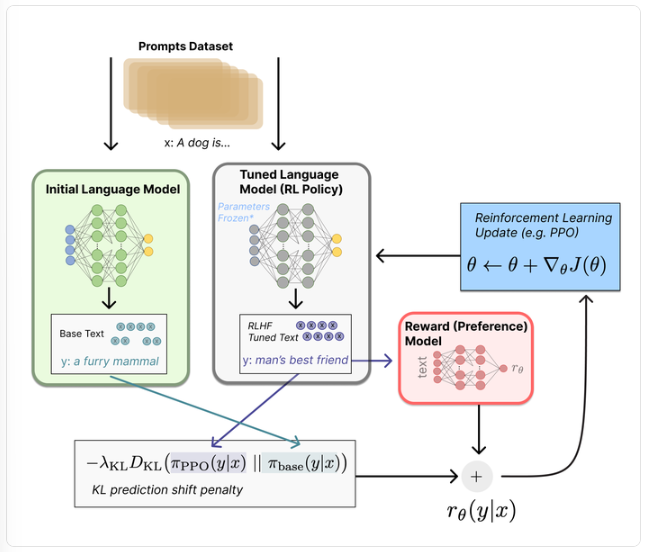

In [69]:
with NaiveStrategy().model_init_context():
    actor = GPTActor(pretrained='models/output_1_SFT', lora_rank=0).to(torch.cuda.current_device())
    critic = GPTCritic(pretrained='models/output_2_RM', lora_rank=0).to(torch.cuda.current_device())
    tokenizer = AutoTokenizer.from_pretrained(
        'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
        padding_side="right",
        model_max_length=512
    )
    initial_model = deepcopy(actor)
    reward_model = RewardModel(deepcopy(critic.model), deepcopy(critic.value_head)).to(torch.cuda.current_device())

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

- 모델학습에 사용할 옵티마이저와 모델을 준비합니다.

In [70]:
actor_optim = torch.optim.Adam(actor.parameters(), lr=5e-6)
critic_optim = torch.optim.Adam(critic.parameters(), lr=5e-6)

In [71]:
(actor, actor_optim), (critic, critic_optim), reward_model, initial_model = NaiveStrategy().prepare( \
    (actor, actor_optim), (critic, critic_optim), reward_model, initial_model)

- PPO 학습에 쓸 데이터를 불러와 토크나이징 해줍니다.

In [73]:
# data_path_3_PPO = 'KoChatGPT/data_kochatgpt/kochatgpt_3_PPO.jsonl'
data_dir = os.path.expanduser('~/work/KoChatGPT/data_kochatgpt')
data_path_3_PPO = os.path.join(data_dir, 'kochatgpt_3_PPO.jsonl')

with open(data_path_3_PPO, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)
    list_prompt = [tmp['prompt'] for tmp in list_data_dict]

def tokenize_fn(texts):
    batch = tokenizer(texts, return_tensors='pt', max_length=96, padding=True, truncation=True)
    return {k: v.cuda() for k, v in batch.items()}

In [74]:
print(tokenize_fn('It takes something more than intelligence to act intelligently.'))

{'input_ids': tensor([[  415,   458, 17944,   449,  9792,   457, 11308, 30190, 10929,   451,
         21663, 12779,  9574, 37415, 14308, 12778, 22469, 24971, 48585, 37415,
         14308, 12778, 11756, 18944,   389]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1]], device='cuda:0')}


In [75]:
len(list_prompt)

12000

- PPO는 별도의 PPOTrainer 클래스를 설계하여 학습시켜줘야 합니다.

빠르게 실습해보기 위해 1epoch만 돌려보겠습니다.

In [76]:
trainer = PPOTrainer(NaiveStrategy(),
                     actor,
                     critic,
                     reward_model,
                     initial_model,
                     actor_optim,
                     critic_optim,
                     max_epochs=1,
                     train_batch_size=8,
                     tokenizer=tokenize_fn,
                     max_length=128,
                     do_sample=True,
                     temperature=1.0,
                     top_k=50,
                     pad_token_id=tokenizer.pad_token_id,
                     eos_token_id=tokenizer.eos_token_id)

위 코드블럭의 원본 코드는 chatgpt/trainer 폴더 내의 ppo.py 모듈에서 확인할 수 있습니다.

PPO는 SFT, RM 보다 훨씬 복잡한 단계로 설계되는 강화학습 알고리즘입니다.

PPO의 loss function은 chatgpt/models 폴더 내의 loss.py 모듈에서 PolicyLoss와 ValueLoss 클래스에 정의되어 있습니다.

- https://gist.github.com/JoaoLages/c6f2dfd13d2484aa8bb0b2d567fbf093#3---fine-tuning-the-lm-with-rl


주관식 퀴즈

Q. 위 링크의 3 - Fine-tuning the LM with RL 부분을 읽어보고 PolicyLoss클래스의 forward메서드에 있는 코드와 비교해보세요.
답변을 적어보세요 😀
<details>
<summary> hint </summary>

Fine-tuning the LM with RL 부분에서는 PPO(Proximal Policy Optimization) 알고리즘을 사용하여, 현재 정책과 기준 정책(또는 이전 정책) 간의 확률 비율(ratio) 를 계산하고,
이 비율에 advantage를 곱한 값을 클리핑(clipping)을 통해 업데이트 폭을 제한합니다.

즉, 행동에 대한 log probability 차이와 클리핑된 비율을 사용하여 정책 손실(policy loss)을 계산합니다.

이 방식은 큰 업데이트로 인한 불안정을 막으면서, 보상이 높은 행동을 더 강화하는 효과를 기대합니다.

PolicyLoss 클래스의 forward 메서드에서는 PolicyLoss 클래스의 forward 메서드 역시 행동의 log probability와 advantage(보상 차이 또는 reward 신호) 를 사용하여 손실을 계산합니다.
두 코드 모두 "보상이 높을수록 해당 행동의 log probability를 증가시켜 손실을 낮추는 방향" 으로 작동하게 됩니다.
</details>

PPO에 대해 좀 더 자세히 알고 싶으신 분들은 허깅페이스에서 제공하는 [Deep RL Course](https://huggingface.co/learn/deep-rl-course/unit8/introduction?fw=pt)를 참고하세요.

- 이제 PPO 학습을 진행하도록 하겠습니다.

In [77]:
trainer.fit(list_prompt,
            num_episodes=10,
            max_timesteps=3,
            update_timesteps=3)

actor.model.save_pretrained('models/output_3_PPO')

Episode [1/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [2/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [3/10]:   0%|          | 0/3 [00:00<?, ?it/s]

...

Episode [9/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Episode [10/10]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/3 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

드디어 SFT, RM 그리고 PPO 학습이 모두 완료되었습니다.
- RLHF가 적용된 koGPT-2의 생성능력을 확인해볼까요?

In [78]:
def generation(input_text, model):
    input_ids = tokenizer.encode(input_text, return_tensors='pt').to(
        torch.cuda.current_device())
    outputs = model.generate(input_ids,
                             max_length=250,
                             do_sample=True,
                             top_k=50,
                             top_p=0.95,
                             num_return_sequences=1)
    output = tokenizer.batch_decode(outputs[0], skip_special_tokens=True)[0]
    print()
    print(output)
    return output

PROMPT_DICT = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

list_prompt = [
    '불고기용 고기 한우에요?',
    '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
    '시카고 오헤어 국제공항은 어디에 있어',
    '오늘 미세먼지 어때?']

list_prompt = [PROMPT_DICT['prompt_input'].format_map({'prompt': tmp}) for tmp in list_prompt]

for input_text in list_prompt:
    output = generation(input_text, actor)


###Instruction(���):����������?###Response(��):'������������.���,�����������������������������.�������������������������������.���������������������������.�����������������.��������,������������������.��������

###Instruction(���):������43������������?###Response(��):'���4�7�16����.���������거������,������������균������������������������������.��,���������������,���������������������������,�����배�����,��배��������������������.

###Instruction(���):����������������###Response(��):'�������������.������.������������������������������.�������������������.������������������������������,������������������������.��,��������������������������,����

###Instruction(���):��������?###Response(��):'���,���������거��������.���,�������거������������������.��,����,�,����������������.�����������������������.��������������������������������.�����������������������.�������,���,�


# 6. 마무리하며
최종 모델 학습 결과는 어떠셨나요?

중복 토큰 생성 문제를 비롯해 맥락에서 벗어난 한문이나 영문이 출력되기도 합니다.

kogpt-2에 SFT만 적용했을 때와 비교해보면 큰 차이를 느끼지 못할 수도 있습니다.

각 단계에서 사용되는 데이터셋을 충분히 정제하고, 훈련 사이클을 늘려 정교하게 디코딩한다면 훨씬 나은 성능을 기대해볼 수 있습니다.

RLHF의 진가는 고도로 정제된 instruction dataset와 정교하게 설계된 보상체계로 학습되는 Reward model, 그리고 PPO 학습이 안정적으로 이뤄질 수 있도록 하는 충분한 크기의 foundation model이 뒷받침 되었을 때 발휘될 수 있습니다.

그러나 진짜 인간의 피드백이 반영된 데이터셋을 구축하기란 아주 어려운 일입니다.

첫 단계부터 큰 난관이라 할 수 있죠.

하지만 SFT만으로도 굉장히 훌륭한 언어모델을 만들 수 있습니다.

이준범님이 공개한 [koalpaca 모델](https://github.com/Beomi/KoAlpaca)이 대표적인 사례라 할 수 있습니다.

주관식 퀴즈

Q. koalpaca는 foundation model로 어떤 모델들을 사용했나요?
답변을 적어보세요 😀
<details>
<summary> hint </summary>

KoGPT-6B와 같이, 사전 학습된 대규모 한국어 GPT 모델을 사용합니다.
</details>


Q. koalpaca의 레퍼런스 모델인 stanford alpaca가 사용한 모델과 데이터셋 그리고 학습방법은 무엇인가요?
답변을 적어보세요 😀
<details>
<summary> hint </summary>

모델 (Foundation Model) : LLaMA (특히 7B 파라미터 버전)
데이터셋: 52K Instruction-Following 데이터셋
학습 방법: Instruction Tuning (Supervised Fine-Tuning)
</details>



충분한 컴퓨팅 파워가 마련된 여건이라면 koalpaca모델로 RLHF까지 진행해 볼 수도 있을 것 같습니다.

그 전에 오늘 노드를 기반으로 도전해 볼만한 과제들을 수행해보는 것이 도움이 될 것 같습니다.

그럼 우리 함께 프로젝트 노드로 이동해볼까요?

# 7. 프로젝트: KoChatGPT 업그레이드 하기
KoChatGPT 소스코드를 바탕으로 다양한 모델 개선 전략을 선택해 KoChatGPT를 업그레이드해 보겠습니다.

아래 제시된 전략 중 하나를 선택하거나 여러 개를 조합하여
여러분만의 custom ChatGPT를 개발해보세요. 물론 더 창의적인 좋은 아이디어를 도입해볼 수도 있겠죠?

복수의 전략을 선택했을 때 혼자서 실험해볼 시간이 부족하다면
팀을 이뤄 분업을 해보셔도 좋습니다!

1. 우리가 지난시간 살펴본 KoChatGPT 모델에 사용한 데이터셋은 아직 완벽히 정제되지 않았습니다.

2. Human Feedback이 반영된 데이터셋을 대체하기 위해
   SFT와 RM 모델에 사용할 다양한 benchmark 데이터셋도 검토해볼 수 있습니다.

3. 언어모델의 생성능력을 좌우하는 최선의 디코딩을 위한 하이퍼파라미터 서치가 필요합니다.

4. 생성된 답변에 대한 주관적인 평가를 보완할 수 있는 정량적인 메트릭은 도입하지 않았었습니다.

5. LLM Trend Note1에서 살펴본 다양한 Instruction Tuning 및 Prompting 기법들도 적용해볼만 합니다.

6. 무엇보다 foundation model로 사용한 KoGPT-2는 Emergent abilities를 기대하기엔 다소 작은 사이즈의 모델입니다.
   더 큰 파라미터 스케일을 가진 모델을 사용해보거나,

7. 더 효율적인 연산을 수행할 수 있는 LoRA의 적용 또는
   새로운 Instruction Tuning 및 reward ranking 알고리즘을 도입해볼 수도 있습니다.


어떤 걸 해야할 지 감이 잡히지 않는 분들을 위해
몇 가지 예시를 소개해드리도록 하겠습니다.

## 기존 데이터셋 추가 정제
data_kochatgpt 폴더에는 세 파일이 있습니다.

- ㄱ. kochatgpt_1_SFT.jsonl : SFT를 위한 prompt와 completion 문장셋

- ㄴ. kochatgpt_1_RM.jsonl : RM 학습을 위한 prompt와 세 가지 ranking 문장셋

- ㄷ. kochatgpt_1_PPO.jsonl : promt 문장

각 말뭉치를 EDA하여 도메인과 문체, 길이분포, 문장의 완성도 등을 분석합니다.

언어모델의 문장생성능력은 말뭉치의 전처리 수준에 큰 영향을 받습니다.

말뭉치의 분석결과를 토대로 데이터를 정제하여 모델을 재학습시켜봅니다.

(정제후 데이터셋 크기가 줄어들지 않도록, 다양한 augmentation 기법을 활용하여 크기를 유지 내지 증량합니다.)

추가 전처리 후, 기존 인퍼런스 결과와 성능을 비교해봅니다.

(주관적인 평가와 BLEU, ROUGE 등을 활용한 정량적인 평가 결과를 비교 분석하여 제시합니다.)

## 새로운 데이터셋 추가
KoChatGPT는 human feedback이 반영된 데이터를 직접 사용하는 대신 ChatGPT API를 사용하는 대안을 선택했습니다.

LLM Trend Note1 에서 살펴보았듯이 Anthropic의 RLHF는 StackExchange 같은 온라인 상의 댓글정보를 활용하여
ranking dataset을 구축해 구현되었습니다.

우리도 비슷한 로직을 적용해볼 수 있습니다.

하나의 prompt에 대한 다양한 수준의 품질로 댓글이 달린 한국어로 된 웹사이트를 찾아봅시다.

웹크롤링 기법을 사용해 reward 점수를 차등적으로 적용해볼 수 있는 instruction dataset과 ranking dataset을 구축해봅니다.

KorQuAD 2.0 같은 한국어 이해 benchmark를 활용해 고품질의 데이터셋을 확보하고, KoGPT-2를 사용해 빠르게 저품질 데이터셋을 페어링해볼 수도 있습니다.

다양한 데이터 증량전략을 구사하여 기존 데이터셋에 새로 구축한 데이터셋을 추가해 모델을 재학습시키고 추론 결과를 비교해 분석하여 제시해보세요.

## foundation model 교체
현재 제공되는 LMS GPU 사양으로는 수십 billion 단위 이상의 LLM을 튜닝하기 어렵습니다.

그러나 허깅페이스에서 제공하는 큰 규모의 모델을 적은 컴퓨팅 자원으로도 사용할 수 있게 해주는 경량화, 최적화 라이브러리를 사용하면 속도는 느리지만 우리의 LMS에서도 학습 및 추론이 가능해질 수 있습니다.

(힌트 : LLM Trend Note1 노드의 마지막 스텝을 참고해보세요)

허깅페이스에서 제공되는 1.2B 사이즈의 한국어 GPT pretrain model로 [skt/ko-gpt-trinity-1.2B-v0.5](https://huggingface.co/skt/ko-gpt-trinity-1.2B-v0.5) 가 있습니다.

해당 모델로 foundation model을 교체해보세요.

(단 OOM(Out Of Memory) 문제를 해소하기 위해 허깅페이스에서 제공하는 다양한 training argument들을 조합하여 최상의 하이퍼파라미터를 찾아내야 합니다.)

데이터셋을 아예 바꿔 모델 선택의 폭을 늘려보는 것도 좋은 선택지입니다.

foundation model 교체에 성공했다면, generator 함수를 수정하여 모델 인퍼런스 결과를 제시해보세요.

참고
LLM Trend Note2 노드에서 살펴본 chatgpt 소스코드는
빠르게 baseline모델을 설계해 실습해보기 위해 오리지널 코드를 일부 수정한 버전입니다.

프로젝트 진행을 위해 모델을 커스터마이징할 때, 필요시 "colossalai_ChatGPT_230319" 폴더 내의 원본 스크립트들을 참고하세요.